# Supplemental, find eta for the chromatin

Compute regularization term to limit the difference between halted cells and RG1.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.config import load_default_chrom_configs
from src.combined_chromatin_model import CombinedChromatinModel

config1, config2 = load_default_chrom_configs()

combined_model = CombinedChromatinModel(config1=config1, config2=config2)

chrom = 1
mnase_span = 45000, 45100

# Load window to deconvolve
combined_model.load_mnase_span(chrom, mnase_span)
combined_model.setup_deconv_model(copy_correct=False)


Loading chromosome reads: 1
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (16, 251, 99) to (16, 26, 10)
Loading chromosome reads: 1
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (15, 251, 99) to (15, 26, 10)
Loading copy correction N, Fr, B from output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr


In [3]:
combined_model.deconvolve(gamma=0.07, kappa=0.0, eta=0)

0/260 - 00:00:00.000
Completed - 00:00:35.126


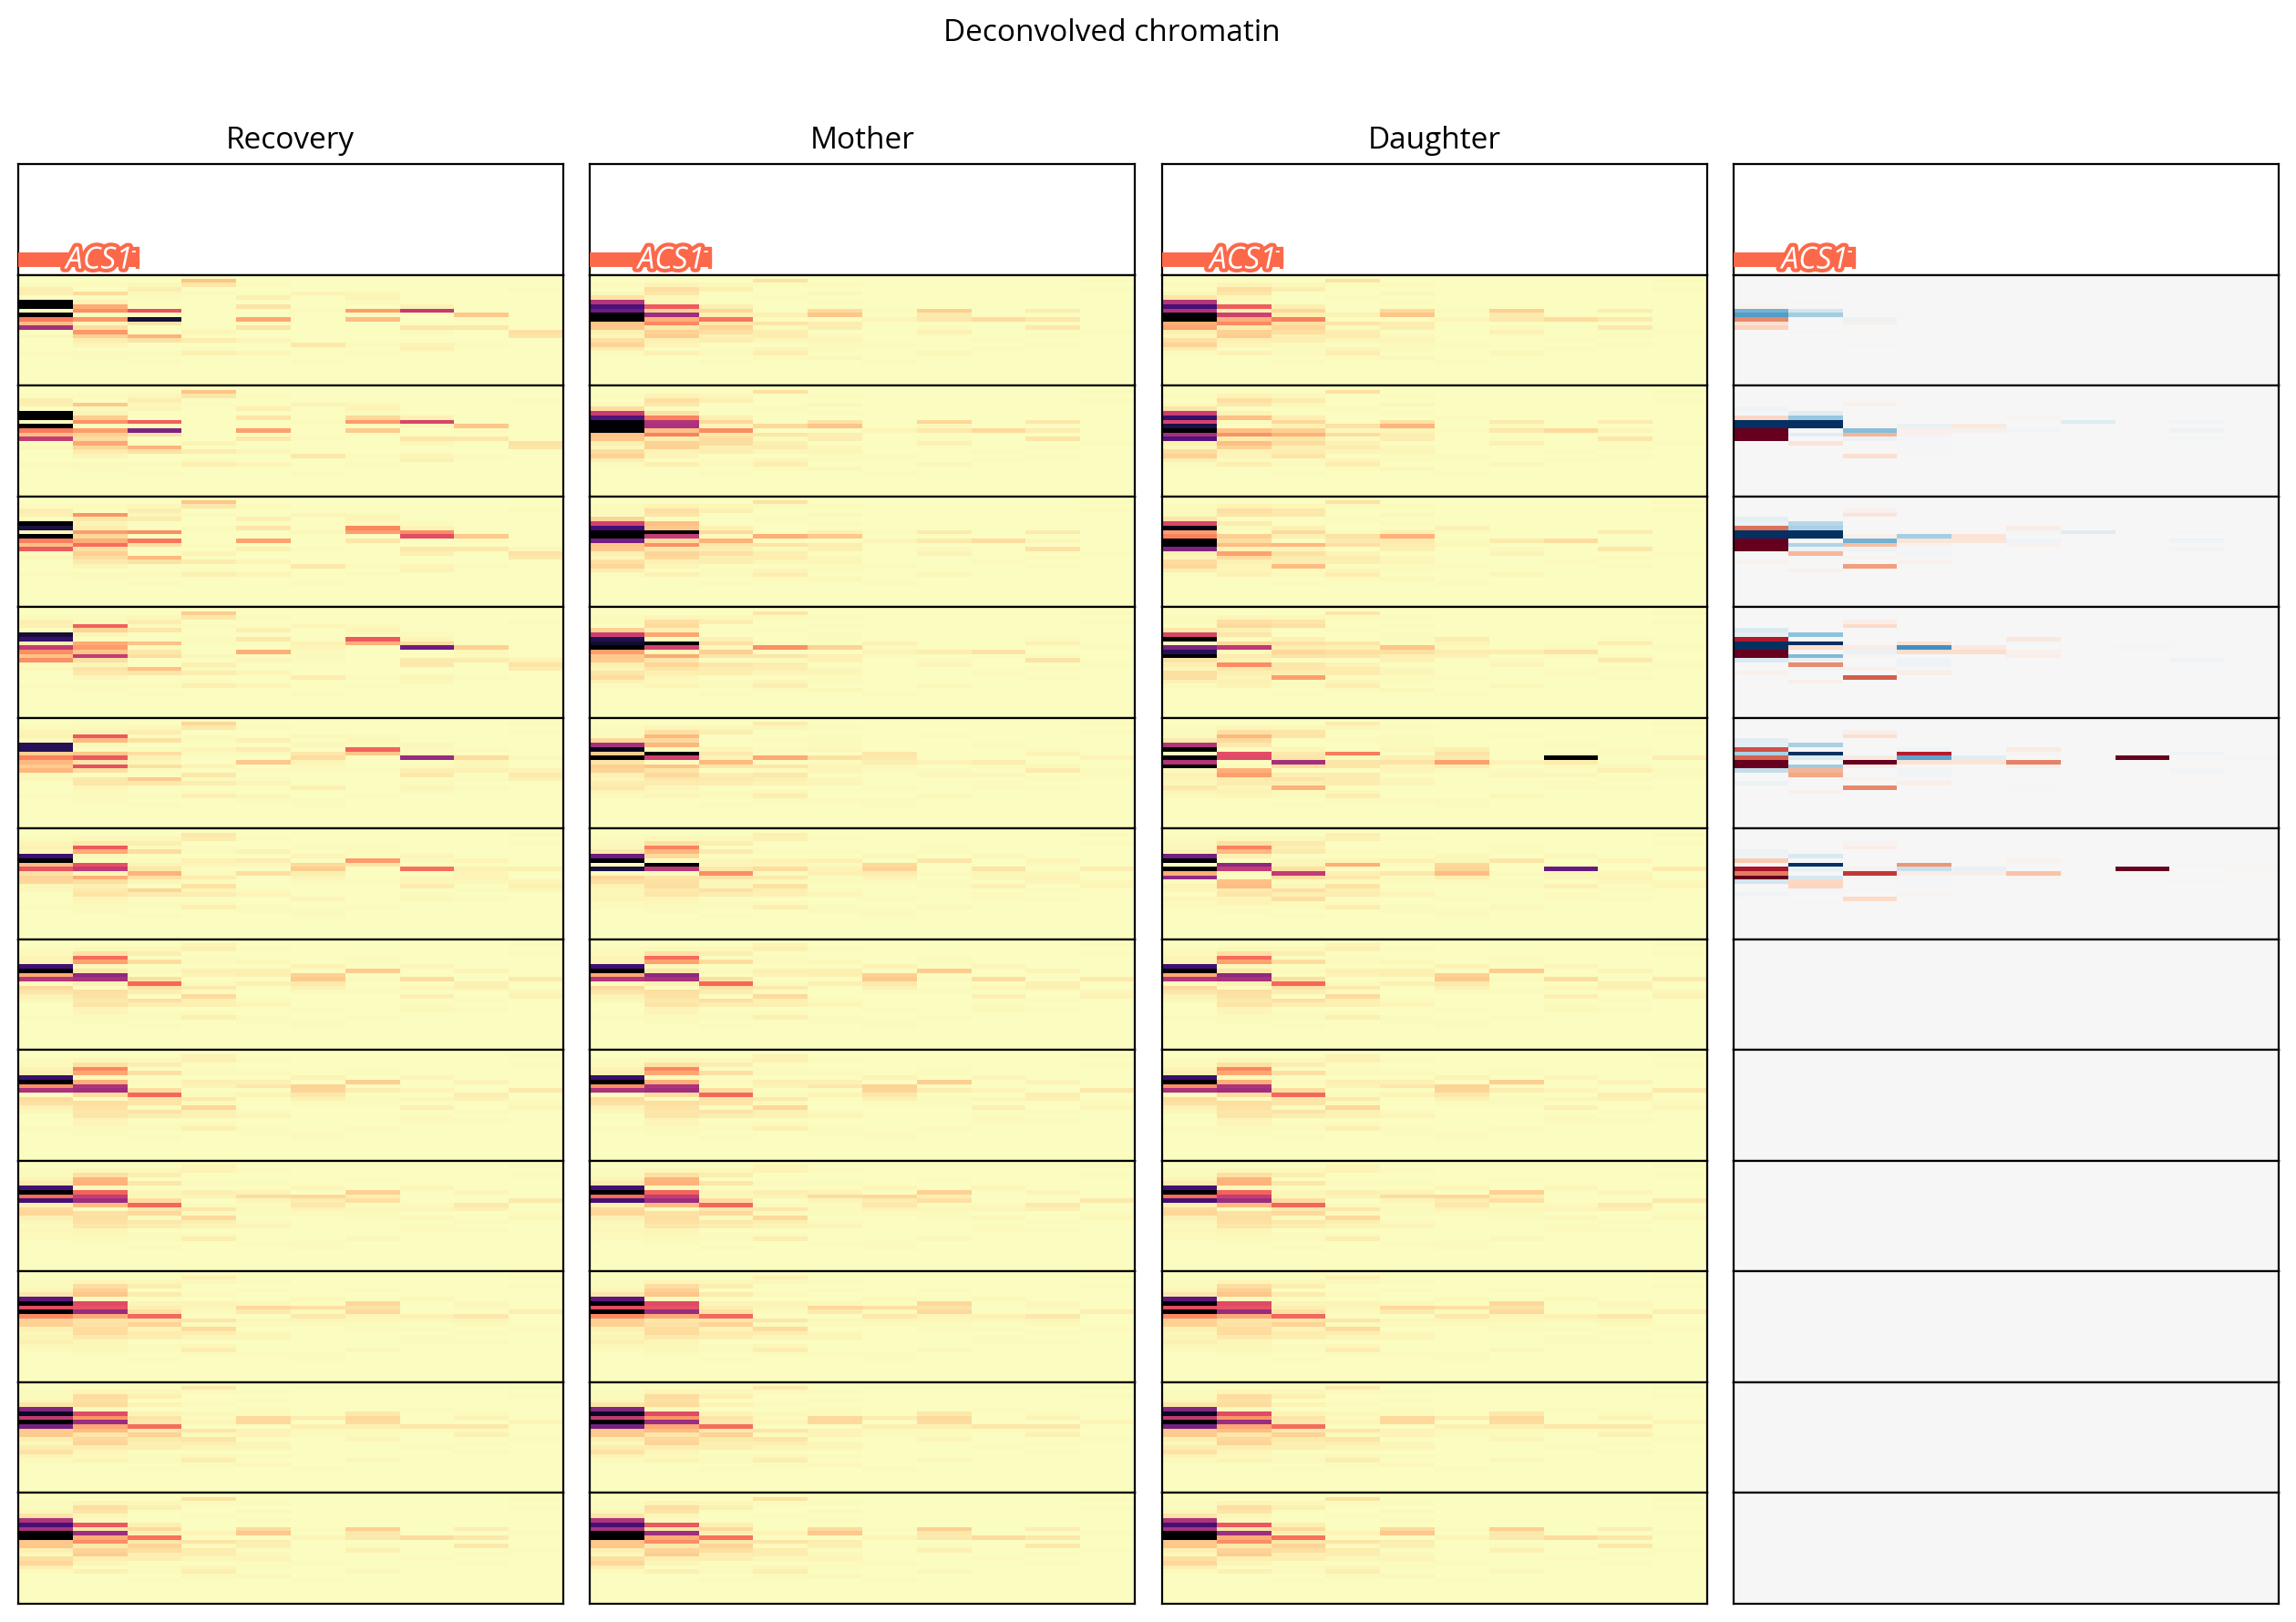

In [4]:
combined_model.plot_branches(figsize=(16, 10))

0/260 - 00:00:00.000
Completed - 00:00:30.618


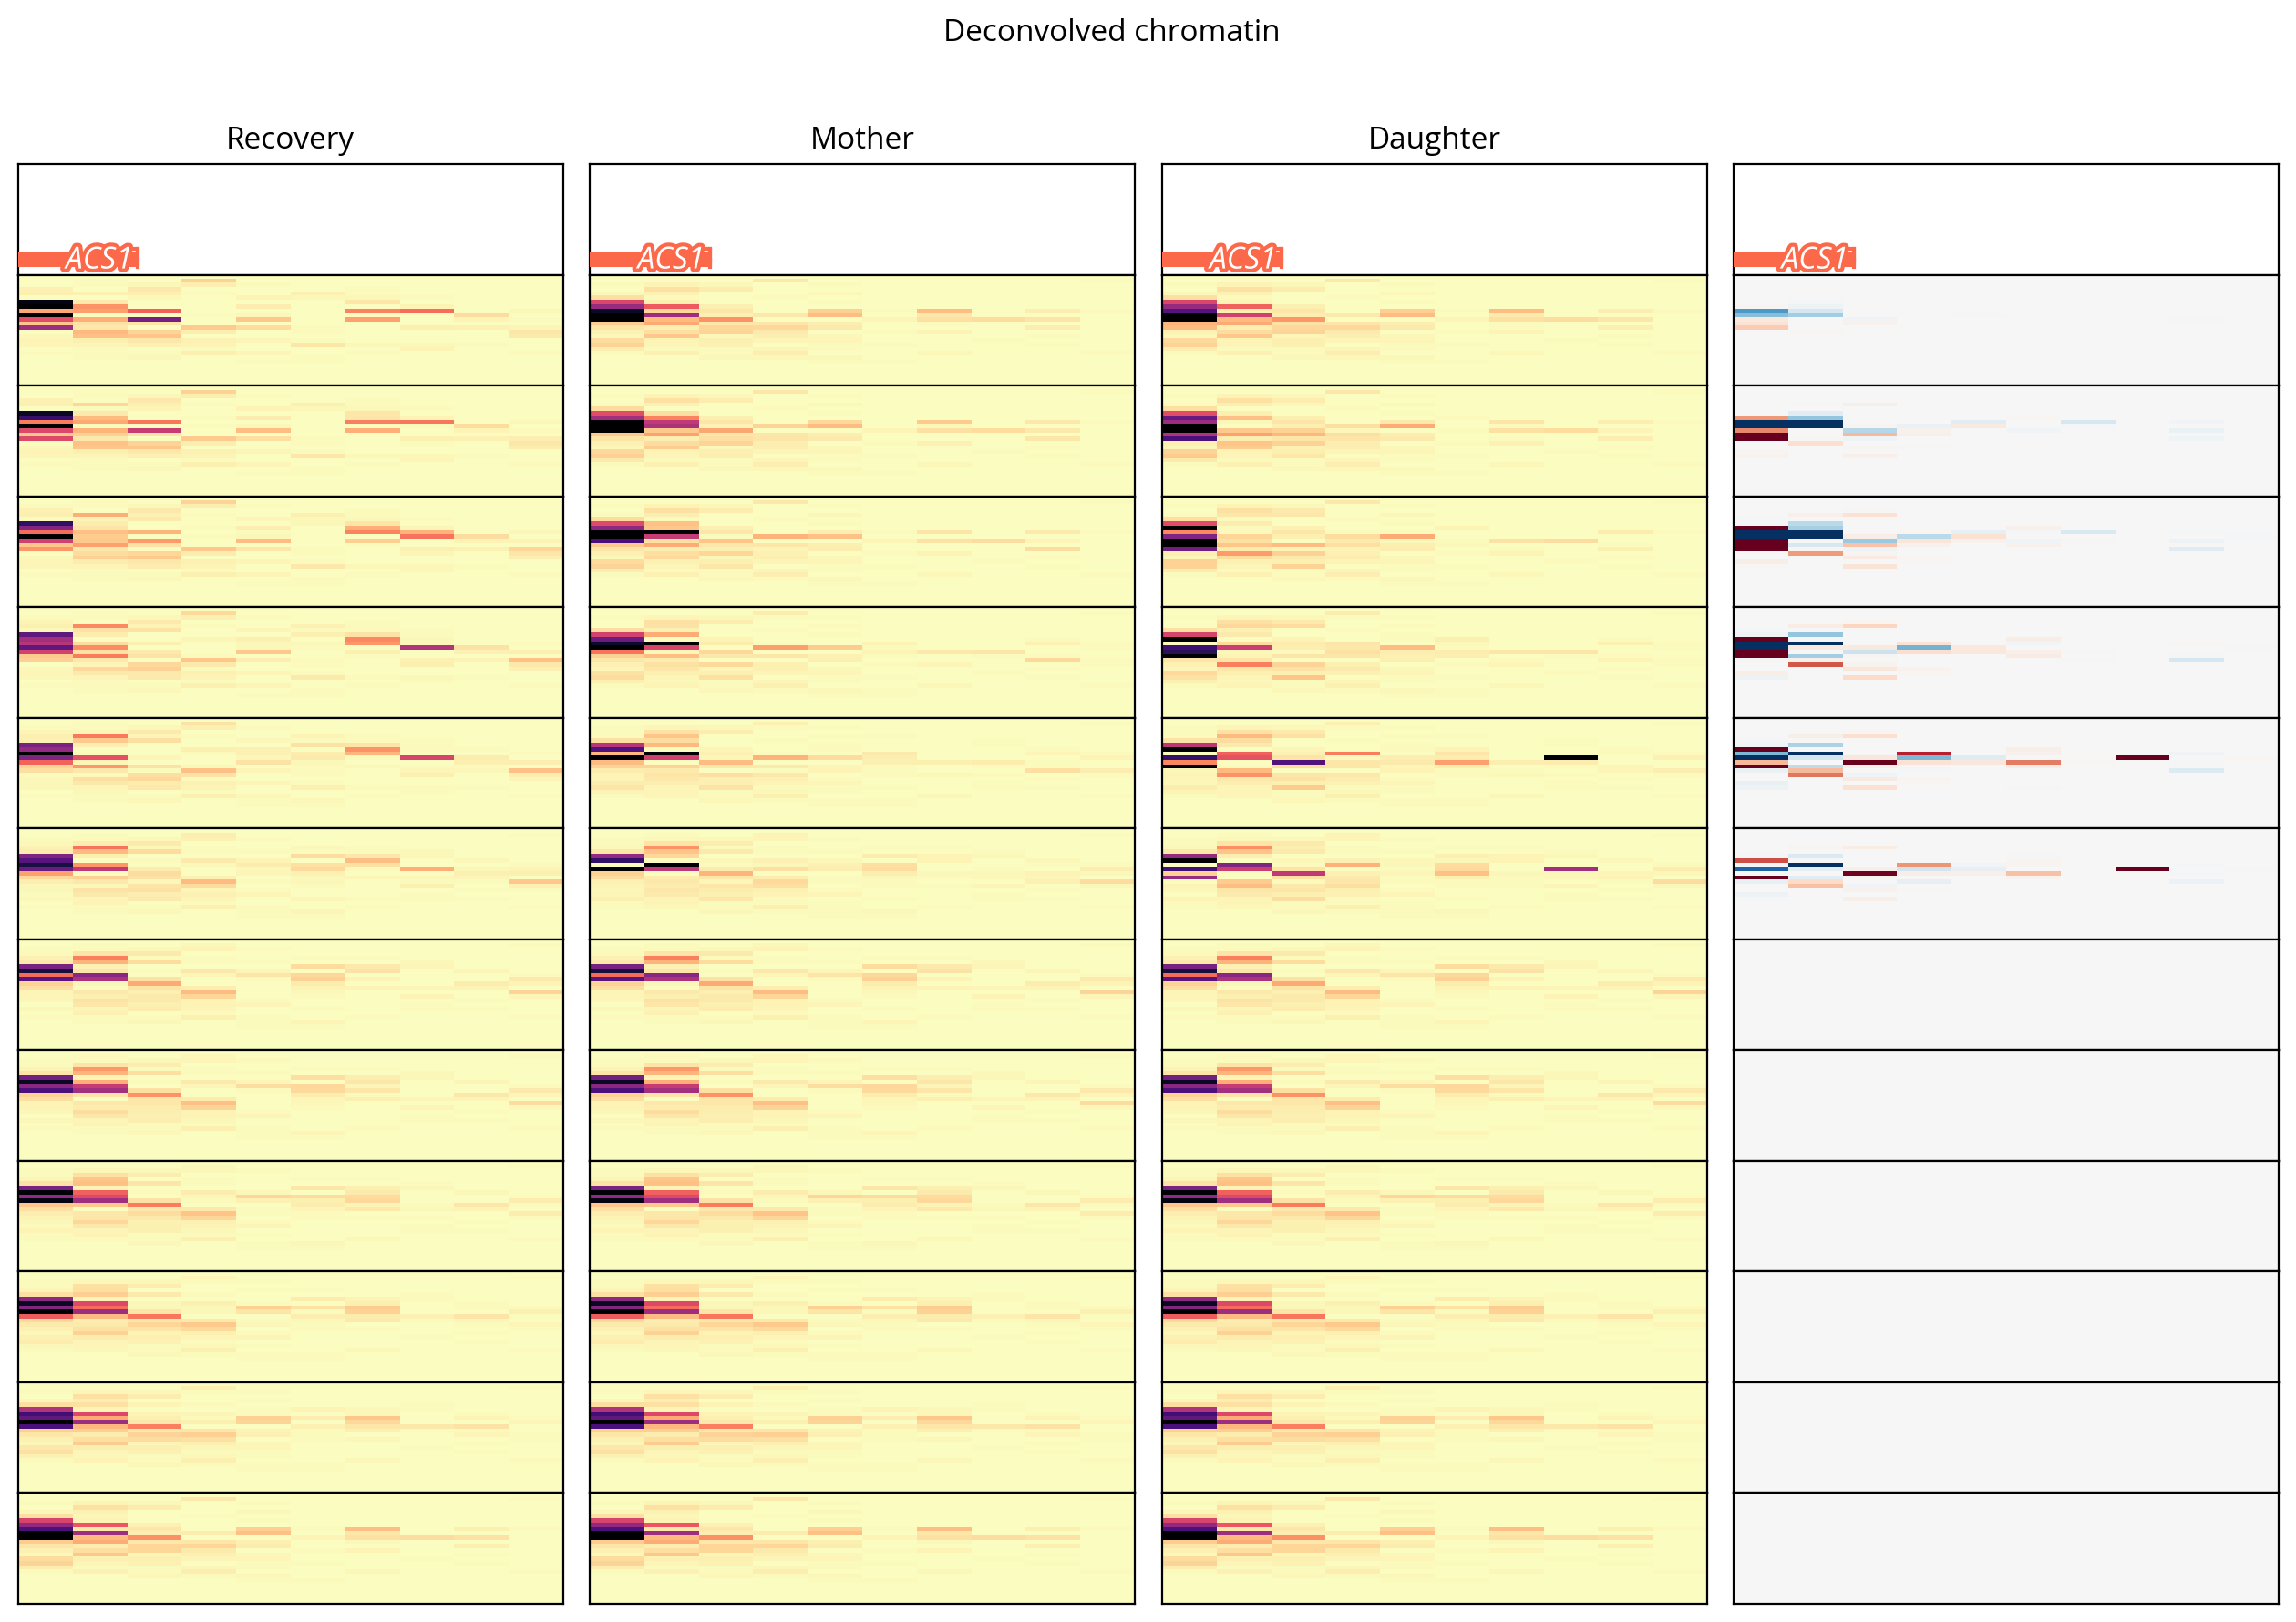

In [19]:
combined_model.deconvolve(gamma=0.07, kappa=0.0, eta=10)
combined_model.plot_branches(figsize=(16, 10))

Loading chromosome reads: 1
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (16, 251, 100) to (16, 26, 10)
Loading chromosome reads: 1
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (15, 251, 100) to (15, 26, 10)
Loading copy correction N, Fr, B from output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr
Running linear eta optimization on chr1:45000-45101
Using gamma=0.07, kappa=0.005
Step 1: Finding et

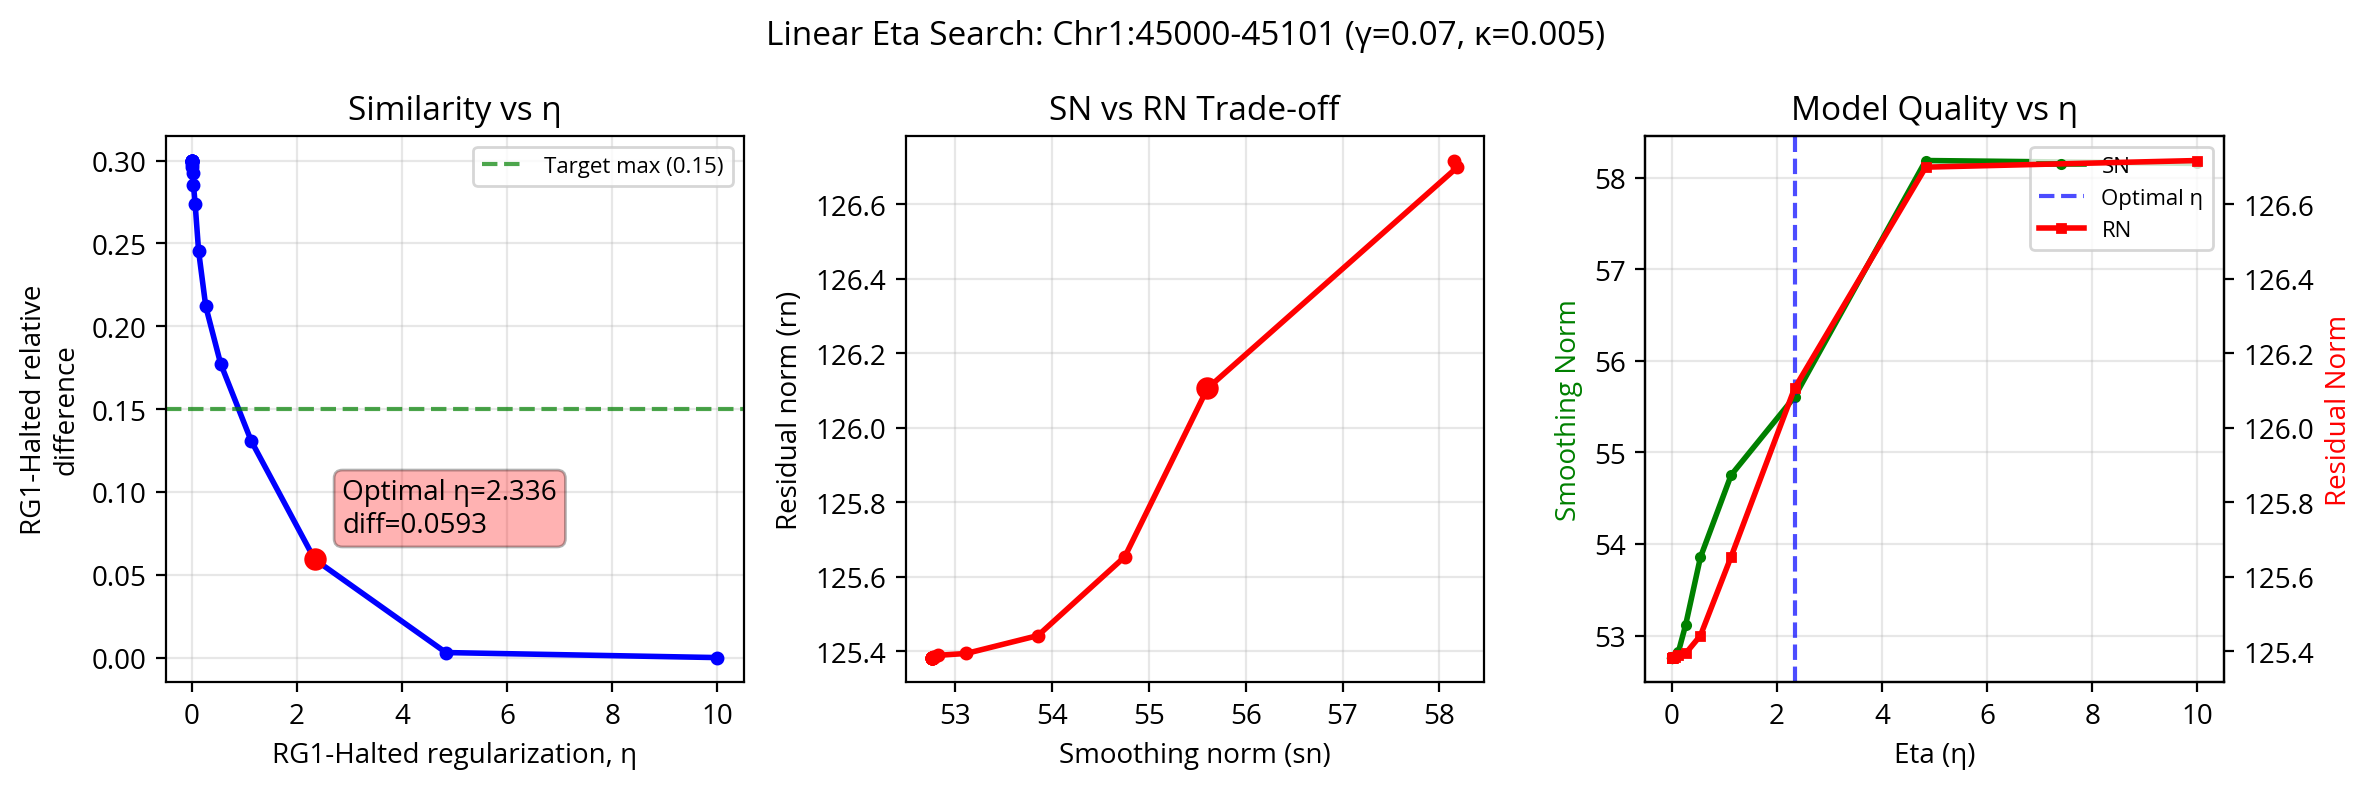

In [30]:
from src.chromatin_find_eta import EtaOptimizer

output_dir = 'output/draft3_run'
save_dir = f"{output_dir}/find_eta_chromatin"

# Initialize with fixed gamma/kappa
optimizer = EtaOptimizer(output_dir, save_dir, gamma=0.07, kappa=0.005)

# Set region
optimizer.set_chromosome_span(chrom=1, mnase_span=(45000, 45101))

# Find optimal eta
optimal_eta, results_df = optimizer.find_optimal_eta_linear()
